for dataset 1:
1. k nearest neighbours classifiers for k=1,5,9


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import math
from mpl_toolkits.mplot3d import Axes3D 
from typing import Callable
from collections import Counter
from scipy.spatial import KDTree
import seaborn as sns
# i tried to display the data from one of the files but the output was truncated to fewer digits, this following line exists to prevent that 
np.set_printoptions(suppress=False, precision=16)

In [104]:
def process_data(filepath: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    """
    Args:
        filepath: string -> file that contains the data 
    
    Returns:
        X,Y where
        X: np.ndarray of size (N, dim_in) 
        Y: np.ndarray of size (N, dim_out)
        
    """
    df = pd.read_csv(filepath)

    # dynamically separate input and output columns 
    input_cols = [col for col in df.columns if col.lower().startswith("x")]
    output_cols = [col for col in df.columns if col.lower().startswith("l")]

    # convert to numpy arrays for better handlling in the future
    X = df[input_cols].to_numpy()
    Y = df[output_cols].to_numpy()

    return X,Y

# test the above code
X,Y = process_data("./Dataset1/train.csv")
for i in range(5):
    print(Y[i])


def process_data3(datafile, labelfile):
    df = pd.read_csv(datafile)
    X = df[df.columns].to_numpy()
    df = pd.read_csv(labelfile)
    Y = df[df.columns].to_numpy()
    return X,Y

    pass

X1,Y1 = process_data3("./Dataset3/train_data.csv", "./Dataset3/train_label.csv")
type(Y1)

[0.]
[2.]
[1.]
[0.]
[1.]


numpy.ndarray

In [25]:
%%time

class KNNClassifier_slow:
    def __init__(self,n_neighbours):
        self.K = n_neighbours
    
    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.array(Y)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))
        pass

    def predict(self, X):
        predictions = []
        for x in X:
            distances = [self._euclidean_distance(x, x_train) for x_train in X]
            k_idx = np.argsort(distances)[:self.K]
            k_neighbour_labels = [self.Y_train[i] for i in k_idx]
            
            most_common = Counter(np.ravel(k_neighbour_labels)).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions
    
    def accuracy(self, Y_pred,Y):
        N = len(Y)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1 - errors/N


# test code

train_filepath = "./Dataset1/train.csv"
val_filepath = "./Dataset1/val.csv"
X_train, Y_train = process_data(train_filepath)
X_val, Y_val = process_data(val_filepath)
knn = KNNClassifier_slow(n_neighbours=3)
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_train)
print(y_pred)
goodness = knn.accuracy(y_pred, Y_train)
goodness

[np.float64(0.0), np.float64(2.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(0.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(1.0), np.float64(0.

0.9833333333333333

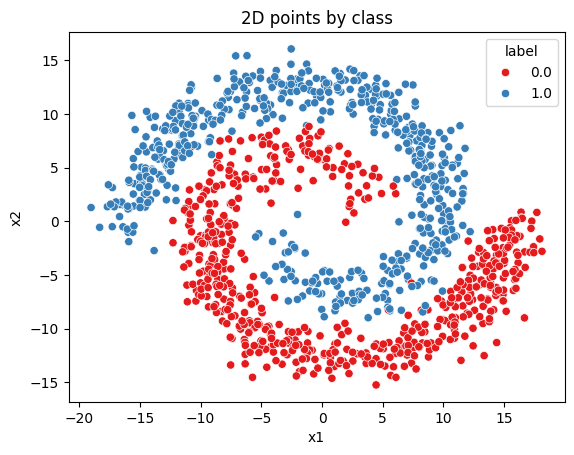

In [28]:
#plot points 
def plot_data(filepath: str):
    data = pd.read_csv(filepath)
    
    sns.scatterplot(data=data, x="x1", y="x2", hue="label", palette="Set1")
    plt.title("2D points by class")
    plt.show()

#test code
train_filepath = "./Dataset2/train.csv"
plot_data(train_filepath)

In [109]:

class KNNClassifier_fast:
    def __init__(self, n_neighbours):
        self.K = n_neighbours
        pass

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.array(Y)
        self.classes = np.unique(self.Y_train)
        self.tree = KDTree(self.X_train)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))
    
    
    def predict(self,X):
        predictions = []

        for x in X:
            distances, indices = self.tree.query(x, k = self.K)
            if self.K==1:
                indices = [indices]
            k_neighbour_labels = [self.Y_train[i] for i in indices]
            most_common = Counter(np.ravel(k_neighbour_labels)).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions
    
    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N


    def plot_decision_region(self):
        #create a mesh
        xmin, xmax = self.X_train[:,0].min()-1, self.X_train[:,0].max()+1
        ymin, ymax = self.X_train[:,1].min()-1, self.X_train[:,1].max()+1
        xx, yy = np.meshgrid(
            np.arange(xmin, xmax, 0.05),
            np.arange(ymin, ymax, 0.05)
        )

        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = self.predict(grid_points)
        Z = np.array(Z).reshape(xx.shape)

        #plot boundary
        plt.contourf(xx, yy, Z,alpha=0.3, cmap = plt.cm.Set1)


        #plot training points
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], 
                              c=self.Y_train, edgecolor='k', cmap=plt.cm.Set1)
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(f"KNN Decision Region (k={self.K})")
        plt.show()
        pass

    def confusion_matrix(self,X,Y):
        y_pred = self.predict(X)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        # avg_precision = np.mean(precisions)
        # avg_recall    = np.mean(recalls)
        # avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures]

        return np.array(cm), metrics
        pass

# test code
train_filepath = "./Dataset3/train.csv"
val_filepath = "./Dataset3/val.csv"
test_filepath = "./Dataset3/test.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")
knn = KNNClassifier_fast(n_neighbours=15)
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_test)
model_accuracy = knn.accuracy(y_pred, Y_test)
confusion_matrix, metrics = knn.confusion_matrix(X_test, Y_test)
print(confusion_matrix)
for item in metrics:
    print(item)
# knn.plot_decision_region()
model_accuracy

    

[[57  3  2 10  8]
 [12 70  4  4  5]
 [18 17 80 50 36]
 [12  8 11 29 27]
 [ 0  2  3  7 24]]
[np.float64(0.7125), np.float64(0.7368421052631579), np.float64(0.39800995024875624), np.float64(0.3333333333333333), np.float64(0.6666666666666666)]
[np.float64(0.5757575757575758), np.float64(0.7), np.float64(0.8), np.float64(0.29), np.float64(0.24)]
[np.float64(0.6368715083798883), np.float64(0.717948717948718), np.float64(0.53156146179402), np.float64(0.3101604278074866), np.float64(0.3529411764705882)]


0.5210420841683367

In [ ]:
import pandas as pd

# confusion matrix

cm, metrics = knn.confusion_matrix(X_test, Y_test)
# cm = [[279, 0, 2],
#       [0, 270, 1],
#       [6, 2, 280]]

df_cm = pd.DataFrame(cm, index=["Class 0","Class 1","Class 2","Class 3","Class 4"],
                        columns=["Class 0","Class 1","Class 2","Class 3","Class 4"])
print(df_cm.to_latex(index=True, caption="Confusion matrix for KNN ($k=15$).", label="tab:conf_matrix"))

# metrics
# metrics = [
#     [0.9928825622775801, 0.996309963099631, 0.9722222222222222],  # Precision
#     [0.9789473684210527, 0.9926470588235294, 0.9893992932862191], # Recall
#     [0.9858657243816255, 0.9944751381215471, 0.9807355516637478], # F1
# ]

for arr in metrics:
    avg = sum(arr)/len(arr)
    arr.append(avg)
    pass

df_metrics = pd.DataFrame(metrics, index=["Precision","Recall","F1-score"],
                          columns=["Class 0","Class 1","Class 2","Class 3","Class 4","Average"])
print(df_metrics.to_latex(float_format="%.3f", caption="Classification metrics for KNN ($k=15$).", label="tab:metrics"))


\begin{table}
\caption{Confusion matrix for KNN ($k=15$).}
\label{tab:conf_matrix}
\begin{tabular}{lrrrrr}
\toprule
 & Class 0 & Class 1 & Class 2 & Class 3 & Class 4 \\
\midrule
Class 0 & 57 & 3 & 2 & 10 & 8 \\
Class 1 & 12 & 70 & 4 & 4 & 5 \\
Class 2 & 18 & 17 & 80 & 50 & 36 \\
Class 3 & 12 & 8 & 11 & 29 & 27 \\
Class 4 & 0 & 2 & 3 & 7 & 24 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Classification metrics for KNN ($k=6$).}
\label{tab:metrics}
\begin{tabular}{lrrrrrr}
\toprule
 & Class 0 & Class 1 & Class 2 & Class 3 & Class 4 & Average \\
\midrule
Precision & 0.713 & 0.737 & 0.398 & 0.333 & 0.667 & 0.569 \\
Recall & 0.576 & 0.700 & 0.800 & 0.290 & 0.240 & 0.521 \\
F1-score & 0.637 & 0.718 & 0.532 & 0.310 & 0.353 & 0.510 \\
\bottomrule
\end{tabular}
\end{table}



In [107]:
import csv

results = []

train_filepath = "./Dataset2/train.csv"
val_filepath = "./Dataset2/val.csv"
test_filepath = "./Dataset2/test.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")

for K in [1,9,15]:
    knn = KNNClassifier_fast(n_neighbours=K)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_train)
    train_err = 1-knn.accuracy(y_pred, Y_train)
    y_pred = knn.predict(X_val)
    val_err = 1-knn.accuracy(y_pred, Y_val)
    y_pred = knn.predict(X_test)
    test_err = 1-knn.accuracy(y_pred, Y_test)

    results.append({
            "K" : K,
            "train_error": train_err,
            "val_error": val_err,
            "test_error": test_err
        }
    )
# Write to CSV
with open("results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)


# Load CSV
df = pd.read_csv("results.csv")

# Convert to LaTeX
with open("results_table.tex", "w") as f:
    f.write(df.to_latex(index=False, float_format="%.3f"))





bayes classifier with one gaussian per class

In [124]:
# separate data based on class
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
class BayesClassifier:
    def __init__(self,same_covariance_matrices:bool ,is_it_naive:bool):
        self.same_covariance_matrices = same_covariance_matrices
        self.is_it_naive = is_it_naive
        pass

    def fit(self,X,Y):
        self.X_train = np.array(X)
        self.Y_train = np.ravel(Y)
        self.classes = np.unique(self.Y_train)
        pass

    def log_gaussian_pdf(self, x, mu, sigma):
        d = x.shape[0]
        return -0.5*d * np.log(2*np.pi) - 0.5*np.log(np.linalg.det(sigma)) - 0.5* np.log((x-mu).T @ (np.linalg.inv(sigma)) @ (x-mu))
        pass

    def log_posterior(self,x, mu, sigma, prior):
        return np.log(prior) + self.log_gaussian_pdf(x, mu, sigma)
        pass

    def predict(self, X):

        #separate data based on class
        classes = np.unique(self.Y_train)
        class_data = {c:self.X_train[self.Y_train==c] for c in classes}

        #estimate parameters for each class
        N = len(self.X_train)
        prior = {c: len(class_data[c])/N for c in classes}
        mu = {c: np.mean(class_data[c], axis=0) for c in classes}
        sigma = {c: np.cov(class_data[c], rowvar=False) for c in classes}

        #for naive bayes classification
        if self.is_it_naive==True:
            sigma = {c: np.diag(np.var(class_data[c], axis=0)) for c in classes}



        #extra step for same cov matrices across all classes
        if self.same_covariance_matrices==True:
            avg_sigma = np.mean([sigma[c] for c in classes], axis=0)
            sigma = {c: avg_sigma for c in classes}

        predictions = []
        for x in X:
            posteriors = {c: (self.log_posterior(x, mu[c], sigma[c], prior[c])) for c in classes}
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
        
        return predictions
    
    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N
    
    def confusion_matrix(self,X,Y):
        y_pred = self.predict(X)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        # avg_precision = np.mean(precisions)
        # avg_recall    = np.mean(recalls)
        # avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures]

        return np.array(cm), metrics
        pass
    
    def plot_level_curves(self, n_std=2.0):
        """
        Plot Gaussian level curves (ellipses) for each class.
        Ellipses are drawn at `n_std` standard deviations (default ~95% confidence).
        """
        if self.X_train.shape[1] != 2:
            raise ValueError("plot_level_curves works only for 2D data.")

        plt.figure(figsize=(8, 6))

        # plot training data
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

            # mean and covariance for this class
            mu = np.mean(X_c, axis=0)
            sigma = np.cov(X_c, rowvar=False)

            # if naive bayes: diagonal cov
            if self.is_it_naive:
                sigma = np.diag(np.var(X_c, axis=0))

            # if same covariance matrices across classes
            if self.same_covariance_matrices:
                all_covs = [np.cov(self.X_train[self.Y_train==d], rowvar=False) for d in self.classes]
                sigma = np.mean(all_covs, axis=0)

            # plot covariance ellipse
            self._plot_cov_ellipse(mu, sigma, n_std=n_std, alpha=0.3)

        plt.title("Bayes Classifier - Gaussian Level Curves")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()


    def _plot_cov_ellipse(self, mean, cov, n_std=2.0, **kwargs):
        """
        Plot an ellipse based on mean and covariance matrix.
        """
        # eigen decomposition
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]

        # compute ellipse angle
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

        # width/height are "n_std" standard deviations
        width, height = 2 * n_std * np.sqrt(vals)

        ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
        plt.gca().add_patch(ellipse)
        def plot_level_curves(self):
            pass

    def plot_decision_region(self, resolution=200, alpha=0.3, show_ellipses=False, n_std=2.0):
        """
        Plot decision regions of the Bayes Classifier (works only for 2D data).
        """
        if self.X_train.shape[1] != 2:
            raise ValueError("plot_decision_region works only for 2D data.")

        # bounds of the grid
        x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
        y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]

        # predict for each grid point
        Z = np.array(self.predict(grid))
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))

        # plot decision regions
        plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.Set2)

        # plot training data
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", edgecolor="k", s=40)

        # optionally overlay Gaussian ellipses
        if show_ellipses:
            for c in self.classes:
                X_c = self.X_train[self.Y_train == c]
                mu = np.mean(X_c, axis=0)
                sigma = np.cov(X_c, rowvar=False)

                if self.is_it_naive:
                    sigma = np.diag(np.var(X_c, axis=0))

                if self.same_covariance_matrices:
                    all_covs = [np.cov(self.X_train[self.Y_train==d], rowvar=False) for d in self.classes]
                    sigma = np.mean(all_covs, axis=0)

                self._plot_cov_ellipse(mu, sigma, n_std=n_std, alpha=0.4, color="black", fill=False)

        plt.title("Bayes Classifier - Decision Regions")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()

        



# test code
train_filepath = "./Dataset2/train.csv"
val_filepath = "./Dataset2/val.csv"
test_filepath = "./Dataset2/test.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")
bc = BayesClassifier(same_covariance_matrices=True, is_it_naive=True)
bc.fit(X_train, Y_train)
y_pred = bc.predict(X_test)
# bc.plot_level_curves()
# bc.plot_decision_region()
model_accuracy = bc.accuracy(y_pred, Y_test)
model_accuracy

0.49699398797595196

In [125]:
import pandas as pd

# confusion matrix

cm, metrics = bc.confusion_matrix(X_test, Y_test)
# print(metrics)
# cm = [[279, 0, 2],
#       [0, 270, 1],
#       [6, 2, 280]]

df_cm = pd.DataFrame(cm, index=[0,1,2,3,4],
                        columns=[0,1,2,3,4])
print(df_cm.to_latex(index=True, caption="Confusion matrix for Naive Bayes with same covariance matrices for all classes.", label="tab:conf_matrix"))

# metrics
# metrics = [
#     [0.9928825622775801, 0.996309963099631, 0.9722222222222222],  # Precision
#     [0.9789473684210527, 0.9926470588235294, 0.9893992932862191], # Recall
#     [0.9858657243816255, 0.9944751381215471, 0.9807355516637478], # F1
# ]

for arr in metrics:
    avg = sum(arr)/len(arr)
    arr.append(avg)
    pass

df_metrics = pd.DataFrame(metrics, index=["Precision","Recall","F1-score"],
                          columns=[0,1,2,3,4, "Average"])
print(df_metrics.to_latex(float_format="%.3f", caption="Classification metrics for Naive bayes with same cov matrices for all classes.", label="tab:metrics"))


\begin{table}
\caption{Confusion matrix for Naive Bayes with same covariance matrices for all classes.}
\label{tab:conf_matrix}
\begin{tabular}{lrrrrr}
\toprule
 & 0 & 1 & 2 & 3 & 4 \\
\midrule
0 & 56 & 6 & 9 & 15 & 9 \\
1 & 12 & 69 & 9 & 10 & 13 \\
2 & 10 & 13 & 59 & 32 & 19 \\
3 & 19 & 11 & 18 & 32 & 27 \\
4 & 2 & 1 & 5 & 11 & 32 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Classification metrics for Naive bayes with same cov matrices for all classes.}
\label{tab:metrics}
\begin{tabular}{lrrrrrr}
\toprule
 & 0 & 1 & 2 & 3 & 4 & Average \\
\midrule
Precision & 0.589 & 0.611 & 0.444 & 0.299 & 0.627 & 0.514 \\
Recall & 0.566 & 0.690 & 0.590 & 0.320 & 0.320 & 0.497 \\
F1-score & 0.577 & 0.648 & 0.506 & 0.309 & 0.424 & 0.493 \\
\bottomrule
\end{tabular}
\end{table}



In [122]:
import csv

results = []

train_filepath = "./Dataset2/train.csv"
val_filepath = "./Dataset2/val.csv"
test_filepath = "./Dataset2/test.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")

for i in range(1):
    bc = BayesClassifier(same_covariance_matrices=False, is_it_naive=True)
    bc.fit(X_train, Y_train)
    y_pred = bc.predict(X_train)
    train_err = 1-bc.accuracy(y_pred, Y_train)
    y_pred = bc.predict(X_val)
    val_err = 1-bc.accuracy(y_pred, Y_val)
    y_pred = bc.predict(X_test)
    test_err = 1-bc.accuracy(y_pred, Y_test)

    results.append({
            # "K" : K,
            "train_error": train_err,
            "val_error": val_err,
            "test_error": test_err
        }
    )

# Write to CSV
with open("results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)


# Load CSV
df = pd.read_csv("results.csv")

# Convert to LaTeX
with open("results_table.tex", "w") as f:
    f.write(df.to_latex(index=False, float_format="%.3f"))


In [5]:
from sklearn.mixture import GaussianMixture

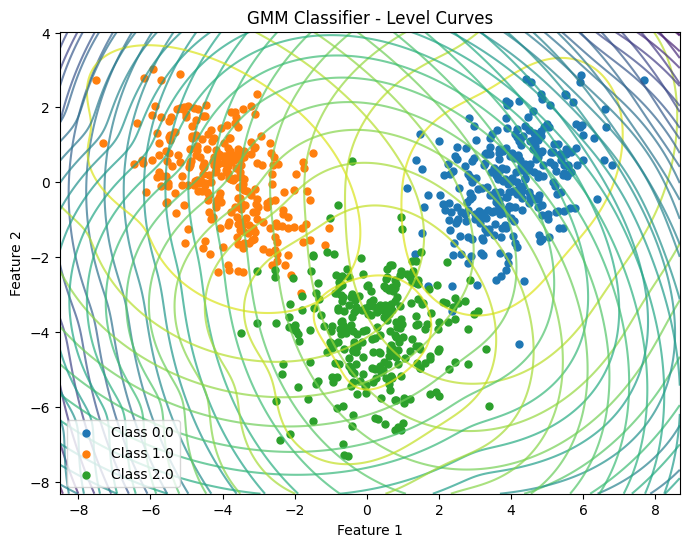

0.9797619047619047

In [ ]:
# #gmm based classifier

# class GMMClassifier:
    
#     def __init__(self, n_components: int, is_covariance_matrix_diagonal: bool):
#         self.n_components = n_components
#         self.is_covariance_matrix_diagonal = is_covariance_matrix_diagonal
#         self.priors = {}
#         self.models = {}
#         pass

#     def fit(self, X, Y):
#         self.X_train = np.array(X)
#         self.Y_train = np.ravel(Y)
#         self.classes = np.unique(self.Y_train)
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train==c]
#             self.priors[c] = len(X_c)/len(self.X_train)
#             gmm = GaussianMixture(n_components=self.n_components, covariance_type="full")

#             #for diag cov matrix do this
#             if self.is_covariance_matrix_diagonal==True:
#                 gmm = GaussianMixture(n_components=self.n_components, covariance_type="diag")
            
#             gmm.fit(X_c)
#             self.models[c] = gmm

#         pass

#     def log_posterior(self,x,c):
#         return np.log(self.priors[c]) + self.models[c].score_samples([x])[0]
#         pass

#     def predict(self, X):
#         predictions = []

#         for x in X:
#             posteriors = {c: self.log_posterior(x, c) for c in self.classes}
#             best_class = max(posteriors, key=posteriors.get)
#             predictions.append(best_class)
        
#         return np.array(predictions)
#         pass

#     def accuracy(self, Y_pred, Y):
#         N = len(Y_pred)
#         errors = 0
#         for i in range(N):
#             if(Y_pred[i]!=Y[i]):
#                 errors+=1
#         return 1- errors/N
    
#     def plot_level_curves(self, resolution=2000):

#         if self.X_train.shape[1] != 2:
#             raise ValueError("plot_level_curves works only for 2D data.")

#         x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
#         y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1
        
#         xx, yy = np.meshgrid(
#             np.linspace(x_min, x_max, resolution),
#             np.linspace(y_min, y_max, resolution)
#         )
#         grid = np.c_[xx.ravel(), yy.ravel()]

#         plt.figure(figsize=(8, 6))

#         # plot training points
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train == c]
#             plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

#         # plot GMM level curves
#         for c in self.classes:
#             gmm = self.models[c]
#             # log probability density
#             Z = gmm.score_samples(grid)
#             Z = Z.reshape(xx.shape)

#             # contour plot
#             plt.contour(xx, yy, Z, levels=20, cmap="viridis", alpha=0.7)

#         plt.title("GMM Classifier - Level Curves")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.legend()
#         plt.show()
    
# # test code
# train_filepath = "./Dataset1/train.csv"
# val_filepath = "./Dataset1/val.csv"
# X_train, Y_train = process_data(train_filepath)
# X_val, Y_val = process_data(val_filepath)
# gc = GMMClassifier(n_components=3, is_covariance_matrix_diagonal = False)
# gc.fit(X_train, Y_train)
# y_pred = gc.predict(X_train)
# model_accuracy = gc.accuracy(y_pred, Y_train)
# gc.plot_level_curves()
# model_accuracy



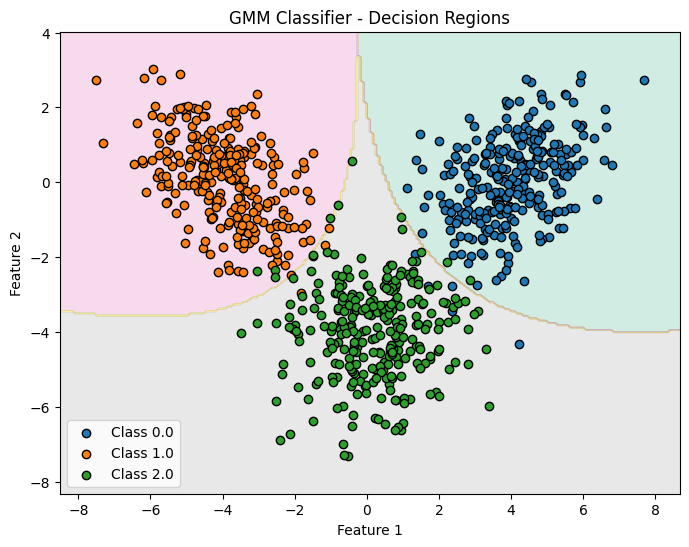

0.9809523809523809

In [ ]:
# #gmm based classifier

# from matplotlib.patches import Ellipse
# import matplotlib.transforms as transforms

# class GMMClassifier:
    
#     def __init__(self, n_components: int, is_covariance_matrix_diagonal: bool):
#         self.n_components = n_components
#         self.is_covariance_matrix_diagonal = is_covariance_matrix_diagonal
#         self.priors = {}
#         self.models = {}
#         pass

#     def fit(self, X, Y):
#         self.X_train = np.array(X)
#         self.Y_train = np.ravel(Y)
#         self.classes = np.unique(self.Y_train)
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train==c]
#             self.priors[c] = len(X_c)/len(self.X_train)
#             gmm = GaussianMixture(n_components=self.n_components, covariance_type="full")

#             #for diag cov matrix do this
#             if self.is_covariance_matrix_diagonal==True:
#                 gmm = GaussianMixture(n_components=self.n_components, covariance_type="diag")
            
#             gmm.fit(X_c)
#             self.models[c] = gmm

#         pass

#     def log_posterior(self,x,c):
#         return np.log(self.priors[c]) + self.models[c].score_samples([x])[0]
#         pass

#     def predict(self, X):
#         predictions = []

#         for x in X:
#             posteriors = {c: self.log_posterior(x, c) for c in self.classes}
#             best_class = max(posteriors, key=posteriors.get)
#             predictions.append(best_class)
        
#         return np.array(predictions)
#         pass

#     def accuracy(self, Y_pred, Y):
#         N = len(Y_pred)
#         errors = 0
#         for i in range(N):
#             if(Y_pred[i]!=Y[i]):
#                 errors+=1
#         return 1- errors/N
    
#     def plot_decision_regions(self, resolution=200, alpha=0.3):
#         if self.X_train.shape[1] != 2:
#             raise ValueError("plot_decision_regions works only for 2D data.")

#         x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
#         y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1

#         xx, yy = np.meshgrid(
#             np.linspace(x_min, x_max, resolution),
#             np.linspace(y_min, y_max, resolution)
#         )
#         grid = np.c_[xx.ravel(), yy.ravel()]

#         # predict class for each grid point
#         Z = self.predict(grid)
#         Z = Z.reshape(xx.shape)

#         plt.figure(figsize=(8, 6))

#         # plot decision regions
#         plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.Set2)

#         # plot training data
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train == c]
#             plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", edgecolor="k")

#         plt.title("GMM Classifier - Decision Regions")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.legend()
#         plt.show()

    
#     def plot_level_curves(self, resolution=2000):

#         if self.X_train.shape[1] != 2:
#             raise ValueError("plot_level_curves works only for 2D data.")

#         x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
#         y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1
        
#         xx, yy = np.meshgrid(
#             np.linspace(x_min, x_max, resolution),
#             np.linspace(y_min, y_max, resolution)
#         )
#         grid = np.c_[xx.ravel(), yy.ravel()]

#         plt.figure(figsize=(8, 6))

#         # plot training points
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train == c]
#             plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

        
#         def plot_cov_ellipse(mean, cov, n_std=2.0, **kwargs):
#             """Plot an ellipse representing the covariance matrix."""
#             pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
#             ell_radius_x = np.sqrt(1 + pearson)
#             ell_radius_y = np.sqrt(1 - pearson)

#             ellipse = Ellipse((0, 0),
#                             width=ell_radius_x * 2,
#                             height=ell_radius_y * 2,
#                             **kwargs)

#             # scale to the right size
#             scale_x = np.sqrt(cov[0, 0]) * n_std
#             scale_y = np.sqrt(cov[1, 1]) * n_std
#             transf = transforms.Affine2D() \
#                 .rotate_deg(45) \
#                 .scale(scale_x, scale_y) \
#                 .translate(mean[0], mean[1])

#             ellipse.set_transform(transf + plt.gca().transData)
#             plt.gca().add_patch(ellipse)

#         # plot GMM level curves
#         for c in self.classes:
#             gmm = self.models[c]
#             for mean, covar in zip(gmm.means_, gmm.covariances_):
#                 if self.is_covariance_matrix_diagonal:
#                     covar = np.diag(covar)  # convert diag to full

#                 plot_cov_ellipse(mean, covar, n_std=2, alpha=0.3)

#         plt.title("GMM Classifier - Level Curves")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.legend()
#         plt.show()
    
# # test code
# train_filepath = "./Dataset1/train.csv"
# val_filepath = "./Dataset1/val.csv"
# X_train, Y_train = process_data(train_filepath)
# X_val, Y_val = process_data(val_filepath)
# gc = GMMClassifier(n_components=1, is_covariance_matrix_diagonal = False)
# gc.fit(X_train, Y_train)
# y_pred = gc.predict(X_train)
# model_accuracy = gc.accuracy(y_pred, Y_train)
# # gc.plot_level_curves()
# gc.plot_decision_regions()
# model_accuracy



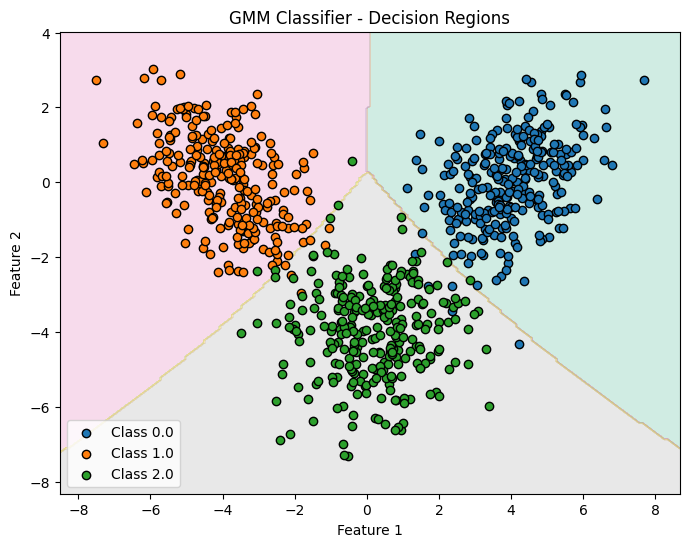

0.9785714285714285

In [ ]:
# #gmm based classifier

# from matplotlib.patches import Ellipse
# import matplotlib.transforms as transforms

# class GMMClassifier:
    
#     def __init__(self, n_components: int, is_covariance_matrix_diagonal: bool):
#         self.n_components = n_components
#         self.is_covariance_matrix_diagonal = is_covariance_matrix_diagonal
#         self.priors = {}
#         self.models = {}
#         pass

#     def fit(self, X, Y):
#         self.X_train = np.array(X)
#         self.Y_train = np.ravel(Y)
#         self.classes = np.unique(self.Y_train)
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train==c]
#             self.priors[c] = len(X_c)/len(self.X_train)
#             gmm = GaussianMixture(n_components=self.n_components, covariance_type="full")

#             #for diag cov matrix do this
#             if self.is_covariance_matrix_diagonal==True:
#                 gmm = GaussianMixture(n_components=self.n_components, covariance_type="diag")
            
#             gmm.fit(X_c)
#             self.models[c] = gmm

#         pass

#     def log_posterior(self,x,c):
#         return np.log(self.priors[c]) + self.models[c].score_samples([x])[0]
#         pass

#     def predict(self, X):
#         predictions = []

#         for x in X:
#             posteriors = {c: self.log_posterior(x, c) for c in self.classes}
#             best_class = max(posteriors, key=posteriors.get)
#             predictions.append(best_class)
        
#         return np.array(predictions)
#         pass

#     def accuracy(self, Y_pred, Y):
#         N = len(Y_pred)
#         errors = 0
#         for i in range(N):
#             if(Y_pred[i]!=Y[i]):
#                 errors+=1
#         return 1- errors/N
    
#     def plot_decision_regions(self, resolution=200, alpha=0.3):
#         if self.X_train.shape[1] != 2:
#             raise ValueError("plot_decision_regions works only for 2D data.")

#         x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
#         y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1

#         xx, yy = np.meshgrid(
#             np.linspace(x_min, x_max, resolution),
#             np.linspace(y_min, y_max, resolution)
#         )
#         grid = np.c_[xx.ravel(), yy.ravel()]

#         # predict class for each grid point
#         Z = self.predict(grid)
#         Z = Z.reshape(xx.shape)

#         plt.figure(figsize=(8, 6))

#         # plot decision regions
#         plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.Set2)

#         # plot training data
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train == c]
#             plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", edgecolor="k")

#         plt.title("GMM Classifier - Decision Regions")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.legend()
#         plt.show()

    
#     def plot_level_curves(self, resolution=2000):

#         if self.X_train.shape[1] != 2:
#             raise ValueError("plot_level_curves works only for 2D data.")

#         x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
#         y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1
        
#         xx, yy = np.meshgrid(
#             np.linspace(x_min, x_max, resolution),
#             np.linspace(y_min, y_max, resolution)
#         )
#         grid = np.c_[xx.ravel(), yy.ravel()]

#         plt.figure(figsize=(8, 6))

#         # plot training points
#         for c in self.classes:
#             X_c = self.X_train[self.Y_train == c]
#             plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

        
#         def plot_cov_ellipse(mean, cov, n_std=2.0, **kwargs):
#             """Plot an ellipse representing the covariance matrix."""
#             pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
#             ell_radius_x = np.sqrt(1 + pearson)
#             ell_radius_y = np.sqrt(1 - pearson)

#             ellipse = Ellipse((0, 0),
#                             width=ell_radius_x * 2,
#                             height=ell_radius_y * 2,
#                             **kwargs)

#             # scale to the right size
#             scale_x = np.sqrt(cov[0, 0]) * n_std
#             scale_y = np.sqrt(cov[1, 1]) * n_std
#             transf = transforms.Affine2D() \
#                 .rotate_deg(45) \
#                 .scale(scale_x, scale_y) \
#                 .translate(mean[0], mean[1])

#             ellipse.set_transform(transf + plt.gca().transData)
#             plt.gca().add_patch(ellipse)

#         # plot GMM level curves
#         for c in self.classes:
#             gmm = self.models[c]
#             for mean, covar in zip(gmm.means_, gmm.covariances_):
#                 if self.is_covariance_matrix_diagonal:
#                     covar = np.diag(covar)  # convert diag to full

#                 plot_cov_ellipse(mean, covar, n_std=2, alpha=0.3)

#         plt.title("GMM Classifier - Level Curves")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.legend()
#         plt.show()
    
# # test code
# train_filepath = "./Dataset1/train.csv"
# val_filepath = "./Dataset1/val.csv"
# X_train, Y_train = process_data(train_filepath)
# X_val, Y_val = process_data(val_filepath)
# gc = GMMClassifier(n_components=1, is_covariance_matrix_diagonal = True)
# gc.fit(X_train, Y_train)
# y_pred = gc.predict(X_train)
# model_accuracy = gc.accuracy(y_pred, Y_train)
# # gc.plot_level_curves()
# gc.plot_decision_regions()
# model_accuracy



In [132]:
#gmm based classifier
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

class GMMClassifier:
    
    def __init__(self, n_components: int, is_covariance_matrix_diagonal: bool):
        self.n_components = n_components
        self.is_covariance_matrix_diagonal = is_covariance_matrix_diagonal
        self.priors = {}
        self.models = {}
        pass

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.ravel(Y)
        self.classes = np.unique(self.Y_train)
        for c in self.classes:
            c = int(c)
        for c in self.classes:
            X_c = self.X_train[self.Y_train==c]
            self.priors[c] = len(X_c)/len(self.X_train)
            gmm = GaussianMixture(n_components=self.n_components, covariance_type="full")

            #for diag cov matrix do this
            if self.is_covariance_matrix_diagonal==True:
                gmm = GaussianMixture(n_components=self.n_components, covariance_type="diag")
            
            gmm.fit(X_c)
            self.models[c] = gmm

        pass

    def log_posterior(self,x,c):
        return np.log(self.priors[c]) + self.models[c].score_samples([x])[0]
        pass

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = {c: self.log_posterior(x, c) for c in self.classes}
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
        
        return np.array(predictions)
        pass

    def accuracy(self, Y_pred, Y):
        N = len(Y_pred)
        errors = 0
        for i in range(N):
            if(Y_pred[i]!=Y[i]):
                errors+=1
        return 1- errors/N
    
    def confusion_matrix(self,X,Y):
        y_pred = self.predict(X)
        y_pred = np.ravel(y_pred)
        y_true = np.ravel(Y)
        
        cm = np.zeros((len(self.classes), len(self.classes)), dtype=int)
        class_to_index = {c:i for (i,c) in enumerate(self.classes)}
        # cm = {c: {d:0 for d in self.classes} for c in self.classes}
        for i in range(len(y_pred)):
            row = class_to_index[y_pred[i]]
            col = class_to_index[y_true[i]]
            cm[row][col]+=1


        row_sums = {c: len(y_true[y_true==c]) for c in self.classes}
        col_sums = {c: len(y_pred[y_pred==c]) for c in self.classes}

        precisions = []
        recalls = []
        f1_measures = []
        for c in self.classes:
            i = class_to_index[c]
            tp = cm[i, i]
            precision = tp / col_sums[c] if col_sums[c] > 0 else 0
            recall    = tp / row_sums[c] if row_sums[c] > 0 else 0
            f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            f1_measures.append(f1)

        # avg_precision = np.mean(precisions)
        # avg_recall    = np.mean(recalls)
        # avg_f1_measure = np.mean(f1_measures)

        metrics = [precisions, recalls, f1_measures]

        return np.array(cm), metrics
        pass
    
    def plot_decision_regions(self, resolution=200, alpha=0.3):
        if self.X_train.shape[1] != 2:
            raise ValueError("plot_decision_regions works only for 2D data.")

        x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
        y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]

        # predict class for each grid point
        Z = self.predict(grid)
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))

        # plot decision regions
        plt.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.Set2)

        # plot training data
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", edgecolor="k")

        plt.title("GMM Classifier - Decision Regions")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()

    
    def plot_level_curves(self, resolution=2000):

        if self.X_train.shape[1] != 2:
            raise ValueError("plot_level_curves works only for 2D data.")

        x_min, x_max = self.X_train[:, 0].min() - 1, self.X_train[:, 0].max() + 1
        y_min, y_max = self.X_train[:, 1].min() - 1, self.X_train[:, 1].max() + 1
        
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]

        plt.figure(figsize=(8, 6))

        # plot training points
        for c in self.classes:
            X_c = self.X_train[self.Y_train == c]
            plt.scatter(X_c[:, 0], X_c[:, 1], label=f"Class {c}", s=25)

        
        def plot_cov_ellipse(mean, cov, n_std=2.0, **kwargs):
            """Plot an ellipse representing the covariance matrix."""
            pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
            ell_radius_x = np.sqrt(1 + pearson)
            ell_radius_y = np.sqrt(1 - pearson)

            ellipse = Ellipse((0, 0),
                            width=ell_radius_x * 2,
                            height=ell_radius_y * 2,
                            **kwargs)

            # scale to the right size
            scale_x = np.sqrt(cov[0, 0]) * n_std
            scale_y = np.sqrt(cov[1, 1]) * n_std
            transf = transforms.Affine2D() \
                .rotate_deg(45) \
                .scale(scale_x, scale_y) \
                .translate(mean[0], mean[1])

            ellipse.set_transform(transf + plt.gca().transData)
            plt.gca().add_patch(ellipse)

        # plot GMM level curves
        for c in self.classes:
            gmm = self.models[c]
            for mean, covar in zip(gmm.means_, gmm.covariances_):
                if self.is_covariance_matrix_diagonal:
                    covar = np.diag(covar)  # convert diag to full

                plot_cov_ellipse(mean, covar, n_std=2, alpha=0.3)

        plt.title("GMM Classifier - Level Curves")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.show()
    
# test code
train_filepath = "./Dataset2/train.csv"
val_filepath = "./Dataset2/val.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")
gc = GMMClassifier(n_components=4, is_covariance_matrix_diagonal = True)
gc.fit(X_train, Y_train)
y_pred = gc.predict(X_test)
model_accuracy = gc.accuracy(y_pred, Y_test)
# gc.plot_level_curves()
# gc.plot_decision_regions()
# confusion_matrix,metrics = gc.confusion_matrix(X_train, Y_train)
# print(confusion_matrix)
# for item in metrics:
#     print(item)
model_accuracy



0.5791583166332666

In [133]:
import pandas as pd

# confusion matrix

cm, metrics = gc.confusion_matrix(X_test, Y_test)
# print(metrics)
# cm = [[279, 0, 2],
#       [0, 270, 1],
#       [6, 2, 280]]

df_cm = pd.DataFrame(cm, index=[0,1,2,3,4],
                        columns=[0,1,2,3,4])
print(df_cm.to_latex(index=True, caption="Confusion matrix for GMM with same diagonal matrices.", label="tab:conf_matrix"))

# metrics
# metrics = [
#     [0.9928825622775801, 0.996309963099631, 0.9722222222222222],  # Precision
#     [0.9789473684210527, 0.9926470588235294, 0.9893992932862191], # Recall
#     [0.9858657243816255, 0.9944751381215471, 0.9807355516637478], # F1
# ]

for arr in metrics:
    avg = sum(arr)/len(arr)
    arr.append(avg)
    pass

df_metrics = pd.DataFrame(metrics, index=["Precision","Recall","F1-score"],
                          columns=[0,1,2,3,4, "Avg"])
print(df_metrics.to_latex(float_format="%.3f", caption="Classification metrics for GMM with diagonal cov matrices for all classes.", label="tab:metrics"))


\begin{table}
\caption{Confusion matrix for GMM with same diagonal matrices.}
\label{tab:conf_matrix}
\begin{tabular}{lrrrrr}
\toprule
 & 0 & 1 & 2 & 3 & 4 \\
\midrule
0 & 68 & 9 & 4 & 11 & 7 \\
1 & 13 & 68 & 6 & 6 & 5 \\
2 & 9 & 7 & 58 & 24 & 13 \\
3 & 7 & 12 & 27 & 43 & 23 \\
4 & 2 & 4 & 5 & 16 & 52 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Classification metrics for GMM with diagonal cov matrices for all classes.}
\label{tab:metrics}
\begin{tabular}{lrrrrrr}
\toprule
 & 0 & 1 & 2 & 3 & 4 & Avg \\
\midrule
Precision & 0.687 & 0.694 & 0.523 & 0.384 & 0.658 & 0.589 \\
Recall & 0.687 & 0.680 & 0.580 & 0.430 & 0.520 & 0.579 \\
F1-score & 0.687 & 0.687 & 0.550 & 0.406 & 0.581 & 0.582 \\
\bottomrule
\end{tabular}
\end{table}



In [128]:
import csv

results = []

train_filepath = "./Dataset2/train.csv"
val_filepath = "./Dataset2/val.csv"
test_filepath = "./Dataset2/test.csv"
X_train, Y_train = process_data3("./Dataset3/train_data.csv","./Dataset3/train_label.csv")
X_val, Y_val = process_data3("./Dataset3/val_data.csv","./Dataset3/val_label.csv")
X_test, Y_test = process_data3("./Dataset3/test_data.csv","./Dataset3/test_label.csv")

for Q in [2,3,4,5]:
    gc = GMMClassifier(n_components=Q, is_covariance_matrix_diagonal=True)
    gc.fit(X_train, Y_train)
    y_pred = gc.predict(X_train)
    train_err = 1-gc.accuracy(y_pred, Y_train)
    y_pred = gc.predict(X_val)
    val_err = 1-gc.accuracy(y_pred, Y_val)
    y_pred = gc.predict(X_test)
    test_err = 1-gc.accuracy(y_pred, Y_test)
    results.append({
            "Q" : Q,
            "train_error": train_err,
            "val_error": val_err,
            "test_error": test_err
        }
    )


# Write to CSV
with open("results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)


# Load CSV
df = pd.read_csv("results.csv")

# Convert to LaTeX
with open("results_table.tex", "w") as f:
    f.write(df.to_latex(index=False, float_format="%.3f"))
